# 01 · Data Exploration
Inspect the raw SPY download and understand the return series before modelling.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data_loader import download_price_data, load_close_series
from src.feature_engineering import compute_log_returns
from src.utils import configure_logging, resolve_path

configure_logging()
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [7]:
TICKER = 'INFY.NS'
START  = '2010-01-01'
END    = '2026-06-01'

raw = download_price_data(TICKER, START, END, resolve_path('data', 'raw'))
close = load_close_series(raw)
print(f'Observations: {len(close):,}  |  {close.index[0].date()} → {close.index[-1].date()}')
close.head()

18:47:13  INFO      src.data_loader — Loading cached data from /Users/shyambanerjee/Program Files/algo_trad/algo_trad_codes/projects/regime_detector/data/raw/INFY.NS_2010-01-01_2026-06-01.csv
Observations: 4,050  |  2010-01-04 → 2026-05-29


Date
2010-01-04    217.472549
2010-01-05    218.200897
2010-01-06    215.016983
2010-01-07    210.184937
2010-01-08    205.119781
Name: Close, dtype: float64

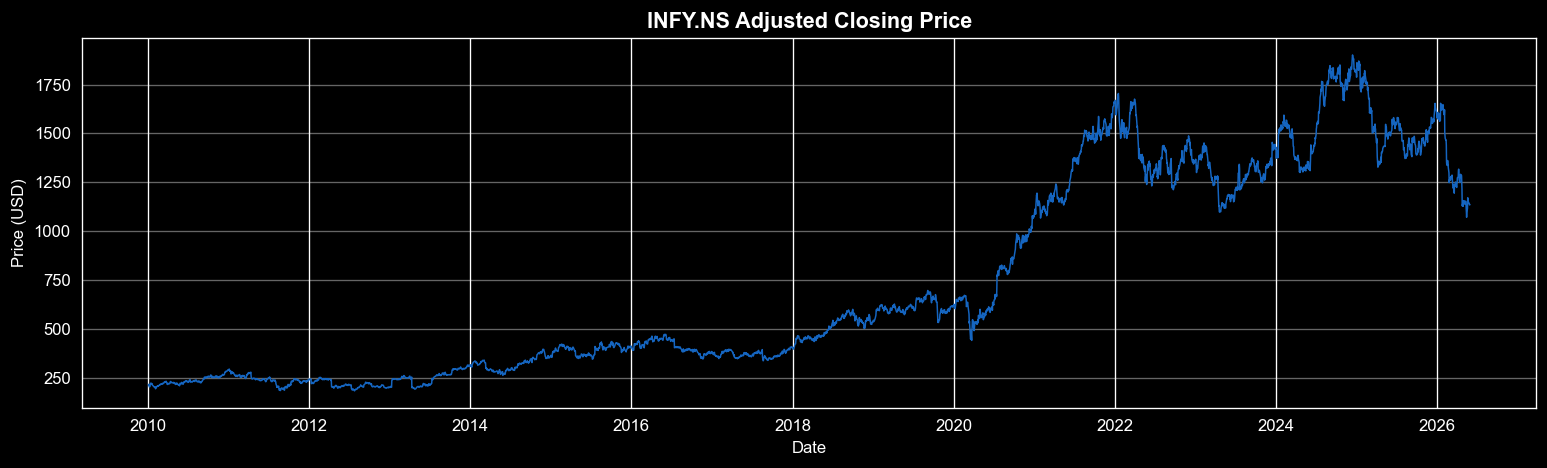

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(close.index, close.values, color='#1565C0', linewidth=0.9)
ax.set_title(f'{TICKER} Adjusted Closing Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()

In [9]:
log_ret = compute_log_returns(close)
print(log_ret.describe())

18:47:19  INFO      src.feature_engineering — Computed 4049 log-return observations (0.0004 mean, 0.017202 std)
count    4049.000000
mean        0.000408
std         0.017202
min        -0.239001
25%        -0.008068
50%         0.000500
75%         0.009524
max         0.155165
Name: log_return, dtype: float64


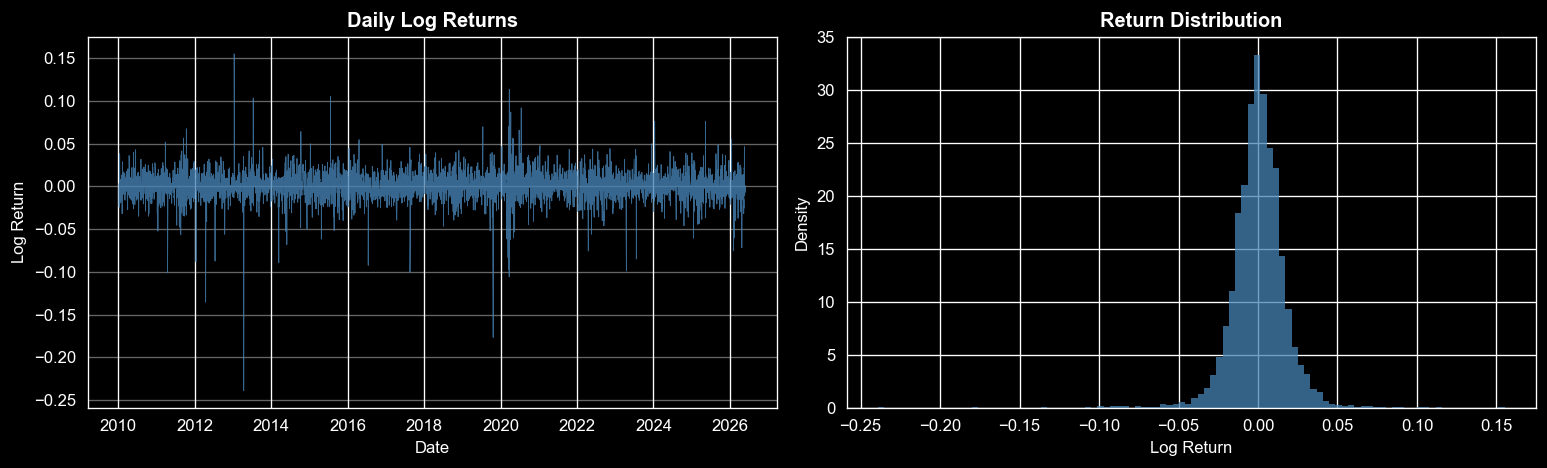

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(log_ret.index, log_ret.values, linewidth=0.5, color='steelblue', alpha=0.8)
axes[0].set_title('Daily Log Returns', fontweight='bold')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Log Return')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(axis='y', alpha=0.4)

axes[1].hist(log_ret.values, bins=100, density=True, color='steelblue', edgecolor='none', alpha=0.75)
axes[1].set_title('Return Distribution', fontweight='bold')
axes[1].set_xlabel('Log Return'); axes[1].set_ylabel('Density')

plt.tight_layout()

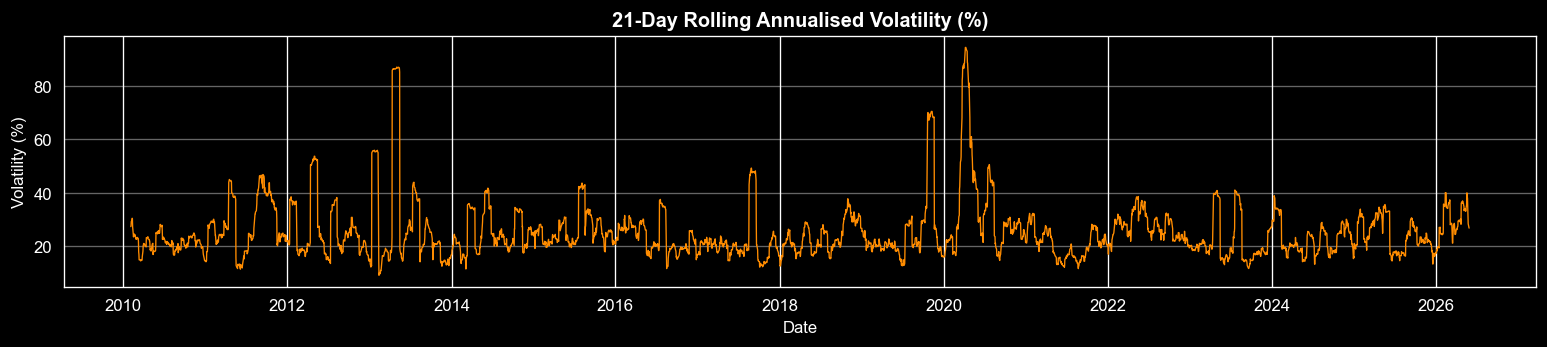

In [11]:
rolling_vol = log_ret.rolling(21).std() * (252 ** 0.5)
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(rolling_vol.index, rolling_vol.values * 100, color='darkorange', linewidth=0.8)
ax.set_title('21-Day Rolling Annualised Volatility (%)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Volatility (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()